In [42]:
import pandas as pd

In [43]:
metrics_table = pd.DataFrame({
    "Model": ["FLAN-T5", "Mistral-Instruct", "GPT-Oss", "T5Gemma"],
    "Cosine Similarity": [
        0.607988,
        0.684687,
        0.462345,
        0.773603
    ],
    "Sentiment Variation": [
        0.873581,
        0.378535,
        0.785549,
        0.669837
    ],
    "Perplexity Variation": [
        432.652486,
        11.311513,
        41.256702,
        58.550725
    ],
    "Style Consistency": [
        0.480000,
        0.840000,
        0.600000,
        0.680000
    ]
})

In [44]:
print(metrics_table.to_string(index=False))

           Model  Cosine Similarity  Sentiment Variation  Perplexity Variation  Style Consistency
         FLAN-T5           0.607988             0.873581            432.652486               0.48
Mistral-Instruct           0.684687             0.378535             11.311513               0.84
         GPT-Oss           0.462345             0.785549             41.256702               0.60
         T5Gemma           0.773603             0.669837             58.550725               0.68


In [45]:
display(
    metrics_table.style
    .hide(axis="index")
    .set_caption("Evaluation Metrics Across Models")
    .format("{:.3f}", subset=metrics_table.select_dtypes("number").columns)
)

Model,Cosine Similarity,Sentiment Variation,Perplexity Variation,Style Consistency
FLAN-T5,0.608,0.874,432.652,0.480
Mistral-Instruct,0.685,0.379,11.312,0.840
GPT-Oss,0.462,0.786,41.257,0.600
T5Gemma,0.774,0.670,58.551,0.680


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [47]:
metrics_table = pd.DataFrame({
    "Model": ["FLAN-T5", "Mistral-Instruct", "GPT-Oss", "T5Gemma"],
    "Cosine Similarity": [0.607988, 0.684687, 0.462345, 0.773603],
    "Sentiment Variation": [0.873581, 0.378535, 0.785549, 0.669837],
    "Perplexity Variation": [432.652486, 11.311513, 41.256702, 58.550725],
    "Style Consistency": [0.480000, 0.840000, 0.600000, 0.680000]
})

In [48]:
metrics = ["Cosine Similarity", "Sentiment Variation", "Perplexity Variation", "Style Consistency"]

In [49]:
df_norm = metrics_table.copy()
for col in metrics:
    # Формула: (x - min) / (max - min)
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())

In [50]:
num_vars = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

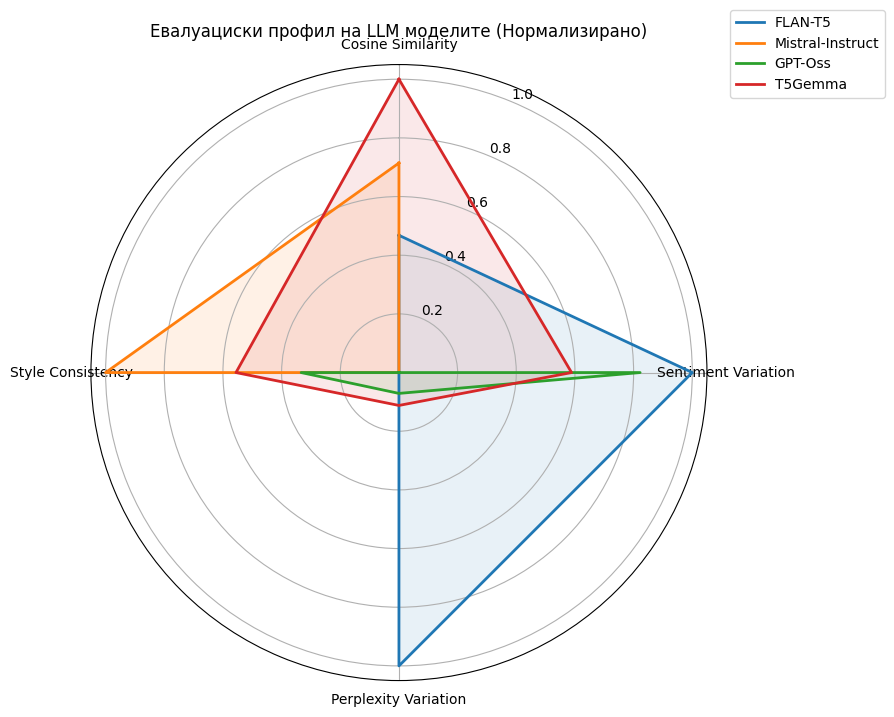

In [51]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, row in df_norm.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row["Model"], linewidth=2)
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Евалуациски профил на LLM моделите (Нормализирано)", pad=20)
plt.show()

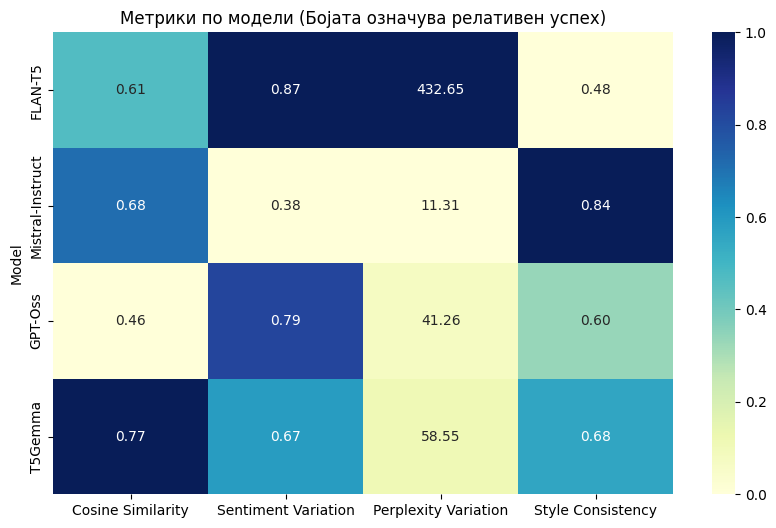

In [52]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_norm.set_index("Model"), annot=metrics_table.set_index("Model"),
            fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Метрики по модели (Бојата означува релативен успех)")
plt.show()

In [53]:
metrics_table = pd.DataFrame({
    "Model": ["FLAN-T5", "Mistral-Instruct", "GPT-Oss", "T5Gemma"],
    "Cosine Similarity": [0.607988, 0.684687, 0.462345, 0.773603],
    "Sentiment Variation": [0.873581, 0.378535, 0.785549, 0.669837],
    "Perplexity Variation": [432.652486, 11.311513, 41.256702, 58.550725],
    "Style Consistency": [0.480000, 0.840000, 0.600000, 0.680000]
})

In [54]:
metrics = ["Cosine Similarity", "Sentiment Variation", "Perplexity Variation", "Style Consistency"]
models = metrics_table["Model"]

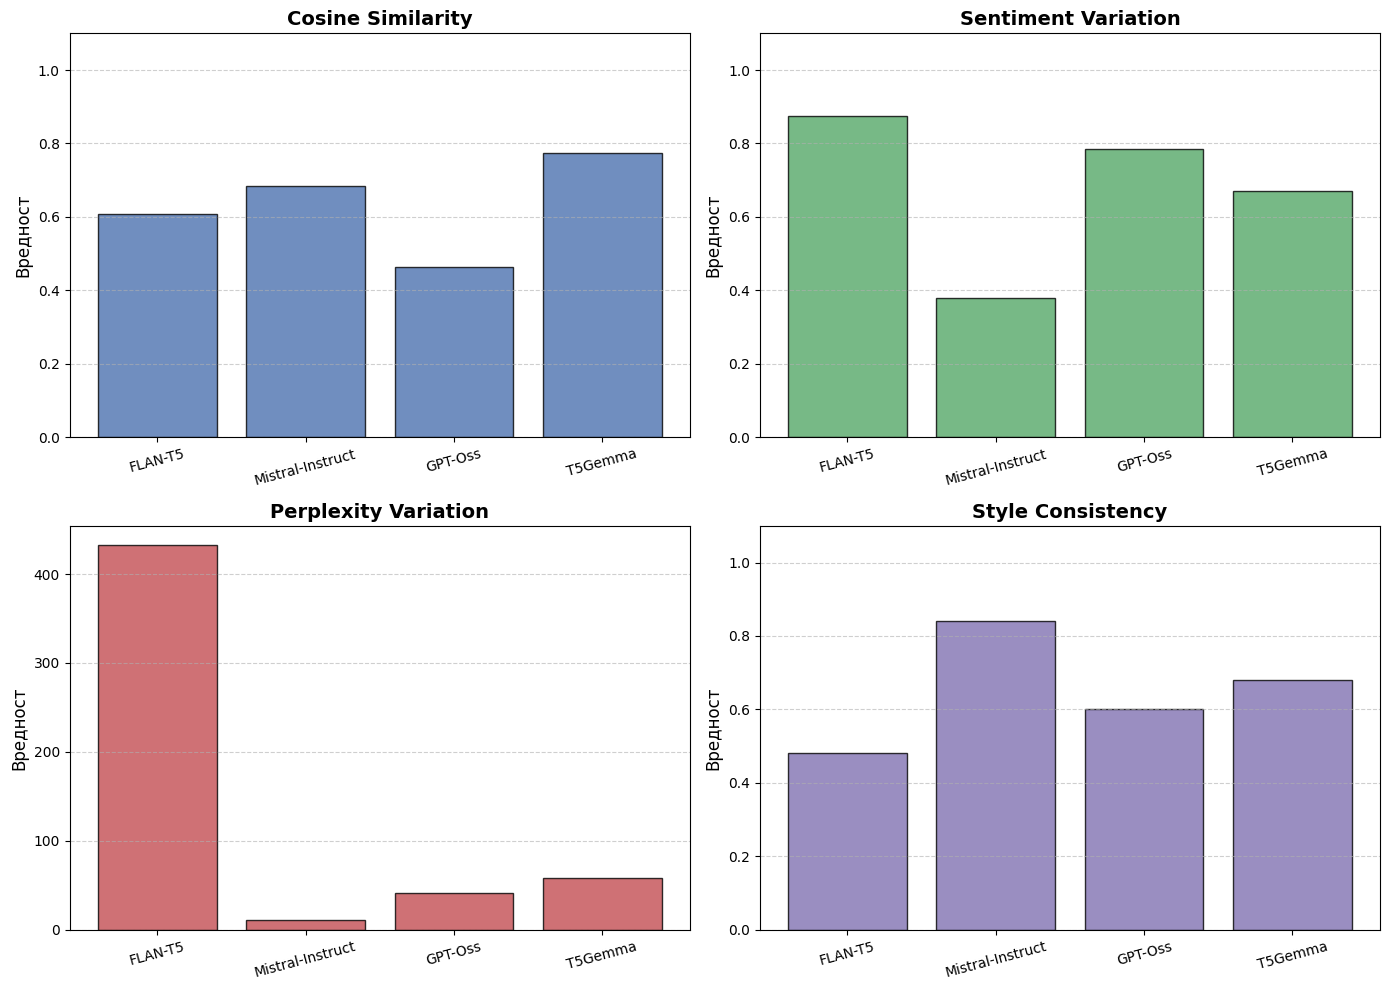

In [55]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, metric in enumerate(metrics):
    axes[i].bar(models, metrics_table[metric], color=colors[i], edgecolor='black', alpha=0.8)

    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Вредност', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

    if metric != "Perplexity Variation":
        axes[i].set_ylim(0, 1.1)

    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()